# Part 1: Checking for quality issues

For this first part I want to check if data is missing, broken or suspicious. Below is a list of questions that this part intends to answer.

* What data do we have that shouldn't be null?
user_id, name, time, rating, gmap_id

* What metadata types do we have that shouldn't be null?
name, address, gmap_id, category, avg_rating, num_of_reviews

* Do we have duplicate entries in our data or metadata?

In [3]:
import sys
import pandas as pd


# open the JSON files
try:
    rd1 = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True, chunksize=1000)
except FileNotFoundError:
    print("File not found")
    sys.exit()

# Check for corresponding gmap_ids
# set up sets because we don't need to worry about duplicates... yet
gmap_id_dset = set()
gmap_id_mset = set()
# append set in chunks for both data and metadata
for chunk in rd1:
    gmap_id_dset|=set(chunk['gmap_id'])
for chunk in rd2:
    gmap_id_mset|=set(chunk['gmap_id'])
# check for gmap_id in data with no corresponding gmap_id in metadata
missing_list = gmap_id_dset - gmap_id_mset
if len(missing_list) > 0:
    print("Missing gmap_ids found:")
    print(list(missing_list))
else:
    print("There are no missing gmap_ids")



There are no missing gmap_ids


It is reassuring to know that there are no missing gmap_ids.

Now to check for duplicates. I decided to count any part of the metadata with the same Name, Address, and gmap_id as a duplicate since no two restaurants would share these three variables and not be a duplicate.

In [3]:
import sys
import pandas as pd

# open the JSON file
try:
    rd2 = pd.read_json('data/meta-Georgia.json', lines=True)
except FileNotFoundError:
    print("File not found")
    sys.exit()

# just get the number of duplicated rows.
print("Number of duplicated rows in metadata:")
print(rd2.duplicated(subset=['name', 'address', 'gmap_id']).sum())


Number of duplicated rows in metadata:
986


A bit concerning. We'll have to remove this after we get the number of duplicated rows in the data.

This will have to be done slightly differently as the file in question is too large for my computer to have the whole file open at once. I will open it in chunks.

In [2]:
import sys
import pandas as pd
# this is more complicated than the last script
duplicate_count = 0
try:
    # make a set (a data type that can't have duplicates)
    keys_seen = set()
    # open the data file in chunks of 1000
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000)
    for chunk in data:
        # zip allows for parallel iteration, allowing for us to speed up this process
        keys = zip(chunk['user_id'], chunk['time'], chunk['gmap_id'])
        for key in keys:
            if key in keys_seen:
                duplicate_count += 1
            else:
                keys_seen.add(key)
except FileNotFoundError:
    print("File not found")
    sys.exit()

print("Number of duplicated rows in metadata:")
print(duplicate_count)


Number of duplicated rows in metadata:
322360


Hundreds of thousands of duplicates is terrible. Now to remove these duplicates.

# Part 2: Complete transformation

The objectives of these two scripts are to:
* Remove duplicates and useless labels
* Replace the pics with the number of pictures
* Place the new .json file within the data folder


In [11]:
import pandas as pd
try:
    rd1 = pd.read_json('data/meta-Georgia.json', lines=True)
    rd1.drop(labels=['description', 'price', 'MISC', 'state', 'relative_results', 'url'], axis=1, inplace=True)
    # drop duplicates from file
    rd1.drop_duplicates(subset=['name', 'address', 'gmap_id'], inplace=True)
    # return cleaned file
    rd1.to_json('data/meta-Georgia_cleaned.json', orient='records', lines=True)
except FileNotFoundError:
    print("File not found")

This reduced the size of the metadata file by 74.39%

In [2]:
import pandas as pd
import numpy as np
keys_seen = set()
boolean_mask = []
try:
    data = pd.read_json('data/review-Georgia.json', lines=True, chunksize=1000, dtype={'user_id':str, 'text':str, 'gmap_id':str})
    for chunk in data:
        chunk['pics'] = chunk['pics'].apply(lambda x: len(x) if isinstance(x, list) else 0)
        chunk['word_count'] = chunk['text'].fillna("").str.split().str.len().astype(np.uint32)
        keys = chunk[['user_id', 'time', 'gmap_id']].itertuples(index=False, name=None)
        for key in keys:
            if key in keys_seen:
                boolean_mask.append(False)
            else:
                boolean_mask.append(True)
                keys_seen.add(key)
        # drops the label last so I can utilize text
        chunk.drop(labels=['name', 'resp', 'text'], axis=1, inplace=True)
        chunk[boolean_mask].to_json('data/review-Georgia_cleaned.json', orient='records', lines=True, mode='a')
        boolean_mask = []
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(e)

This reduced the size of the data file by 56.5%

# Part 3: EDA
Next, I need to do basic analysis of the variables listed in the cleaned .json files.



In [1]:
import pandas as pd
try:
    print("Metadata Statistics")
    df = pd.read_json('data/meta-Georgia_cleaned.json', lines=True)
    print(df.describe())

except FileNotFoundError:
    print("File not found")

Metadata Statistics
            latitude      longitude     avg_rating  num_of_reviews
count  165395.000000  165395.000000  165395.000000   165395.000000
mean       33.432707     -83.858679       4.259773      145.357109
std         0.950851       2.404695       0.676245      369.566285
min        25.126484     -88.100026       1.000000        1.000000
25%        33.041988     -84.472016       4.000000        8.000000
50%        33.773949     -84.218039       4.400000       35.000000
75%        34.000048     -83.658343       4.800000      118.000000
max        42.639763     180.000000       5.000000     9998.000000


Some latitudes and longitudes are improperly entered. We can see that the minimum latitude is south of most of Florida, the maximum latitude is located in the northern U.S. The minimum longitude is west of Georgia's western border, and the maximum longitude is near the international date line.

The overwhelmingly majority of the average rating is positive. The number of reviews that a particular business has ranges from 1-9998.
I had to create a version of the review data including only the variables that would be useful with df.describe.

In [3]:
import pandas as pd
import numpy as np
try:
    df = pd.read_json('data/review-Georgia_cleaned.json', lines=True, dtype={'user_id':str, 'time':np.uint64, 'rating':np.int8, 'gmap_id':str}, chunksize=10000)
    for chunk in df:
        chunk.drop(labels=['user_id', 'gmap_id'], axis=1, inplace=True)
        chunk.to_json('data/review-Georgia_CandR.json', orient='records', lines=True, mode='a')
except FileNotFoundError:
    print("File not found")

In [4]:
import pandas as pd
import numpy as np
try:
    df = pd.read_json('data/review-Georgia_CandR.json', lines=True, dtype={'time':np.uint64, 'rating':np.int8, 'pics':np.uint8})
    # no pandas I don't want this in scientific notation
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    print(df.describe())
except FileNotFoundError:
    print("File not found")


                  time      rating        pics  word_count
count      23707799.00 23570222.00 23707799.00 23707799.00
mean  1551798490370.16        4.23        0.06       17.34
std     44324114719.32        1.24        0.73       38.19
min    946598400000.00        1.00        0.00        0.00
25%   1523875184762.50        4.00        0.00        0.00
50%   1555365798320.00        5.00        0.00        4.00
75%   1582721919769.00        5.00        0.00       18.00
max   1631158941334.00        5.00       50.00     2109.00


I saw RAM usage go up to almost 15GB while running this script.
Next, let's make a histogram to get a better visual.

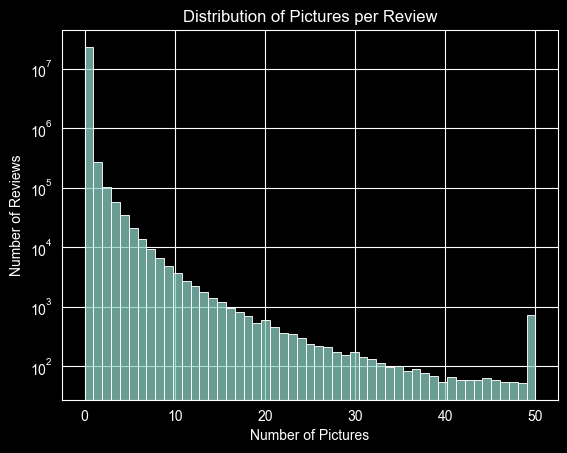

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/review-Georgia_CandR.json', lines=True, dtype={'time':np.uint64, 'rating':np.int8, 'pics':np.uint8})
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['pics'], bins=51)
    plt.xlabel("Number of Pictures")
    plt.ylabel("Number of Reviews")
    plt.title("Distribution of Pictures per Review")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")

This is certainly interesting. We have a steady decline in the number of pictures in reviews up until we reach 50. I think that from this graph we have found people who post the most pictures they can per review.

In [1]:
import pandas as pd
import numpy as np

def compute_diff(t):
    if len(t) <= 1:
        return 0
    st = np.diff(sorted(t))
    if np.mean(st) == 0:
        return 0
    return np.std(st)/np.mean(st)

try:
    # create a data structure that will contain the user_ids (and other info) to add to the rgur_data.json file called data
    data = pd.DataFrame()
    chunk_count = 1
    df = pd.read_json('data/review-Georgia_cleaned.json', lines=True, dtype={'user_id':str, 'time':np.uint64, 'rating':np.int8, 'pics':np.uint8, 'word_count':np.uint16, 'gmap_id':str}, chunksize=1000000)
    for chunk in df:
        print("We have reached chunk " + str(chunk_count))
        chunk_count += 1
        grouped = chunk.groupby('user_id').agg(
            total_pictures=('pics','sum'),
            max_pics=('pics', 'max'),
            total_reviews=('pics', 'count'),
            rev_with_pics=('pics', lambda x: (x>0).sum()),
            total_words=('word_count', 'sum'),
            max_words=('word_count', 'max'),
            rev_with_words=('word_count', lambda x: (x>0).sum()),
            review_times=('time', list),
            ratings=('rating', list),
        )
        if data.empty:
            data = grouped
        else:
            # this line is to add values (excluding max_pics, because then we will get an incorrect max_pics)
            data[['total_pictures','total_reviews','rev_with_pics', 'total_words', 'rev_with_words']] = \
        data[['total_pictures','total_reviews','rev_with_pics','total_words', 'rev_with_words']].add(
            grouped[['total_pictures','total_reviews','rev_with_pics', 'total_words', 'rev_with_words']],
            fill_value=0
            )
            for col in ['review_times', 'ratings']:
                data[col] = data[col].combine(
                grouped[col],
                lambda x, y: (x if isinstance(x, list) else []) +
                     (y if isinstance(y, list) else [])
            )
            data['max_pics'] = np.maximum(
                data['max_pics'],
                grouped['max_pics'].reindex(data.index, fill_value=0)
            )
            data['max_words'] = np.maximum(
                data['max_words'],
                grouped['max_words'].reindex(data.index, fill_value=0)
            )
    data['avg_pictures'] = data['total_pictures'] / data['total_reviews']
    data['pics_percent'] = data['rev_with_pics'] / data['total_reviews'] * 100
    # note to self: do not sort ratings, as it is unnecessary
    data['cov_time'] = data['review_times'].map(compute_diff)
    data['cov_rating'] = data['ratings'].apply(
        lambda r: np.std(r)/np.mean(r)
    )
    data.drop(columns=['review_times', 'ratings'], inplace=True)
    # calculate avg_pictures, pics_percent in list
    data.reset_index().to_json('data/rgur_data.json', orient='records', lines=True)
    # note: this took me 12 minutes and 46 seconds for the program to run initially, but this edit to also include word data expanded that time to 37 minutes and 51 seconds
except FileNotFoundError:
    print("File not found")

We have reached chunk 1
We have reached chunk 2
We have reached chunk 3
We have reached chunk 4
We have reached chunk 5
We have reached chunk 6
We have reached chunk 7
We have reached chunk 8
We have reached chunk 9
We have reached chunk 10
We have reached chunk 11
We have reached chunk 12
We have reached chunk 13
We have reached chunk 14
We have reached chunk 15
We have reached chunk 16
We have reached chunk 17
We have reached chunk 18
We have reached chunk 19
We have reached chunk 20
We have reached chunk 21
We have reached chunk 22
We have reached chunk 23
We have reached chunk 24


This code above creates another JSON file with the following attributes:

* user_id: the user_id
* total_pictures: the cumulative number of pictures in all reviews posted
* max_pics: the largest number of pictures the user posted in one review
* total_reviews: the number of reviews posted by the user
* rev_with_pics: the number of reviews posted by the user with more than 0 pictures attached
* avg_pictures: the average number of pictures this user includes per review.
* pics_percent: the percentage of reviews posted by the user with more than 0 pictures attached

In [2]:
import pandas as pd
try:
    # consider chunks?
    data = pd.read_json('data/rgur_data.json', lines=True)
    data.drop(columns=['user_id'], inplace=True)
    pd.set_option('display.float_format', lambda x: f'{x:.2f}')
    print(data.describe())
except FileNotFoundError:
    print("File not found")

       total_pictures  max_pics  total_reviews  rev_with_pics  total_words  \
count       820735.00 820735.00      820735.00      820735.00    820735.00   
mean             0.79      0.29          10.92           0.27       172.14   
std             11.47      1.78          26.29           2.25       481.45   
min              0.00      0.00           1.00           0.00         0.00   
25%              0.00      0.00           1.00           0.00        13.00   
50%              0.00      0.00           2.00           0.00        50.00   
75%              0.00      0.00           7.00           0.00       148.00   
max           2175.00     50.00        1520.00         311.00     43512.00   

       max_words  rev_with_words  avg_pictures  pics_percent  cov_time  \
count  820735.00       820735.00     820735.00     820735.00 820735.00   
mean       57.17            6.37          0.04          1.50      0.73   
std        77.75           17.40          0.34          8.55      1.08   
m

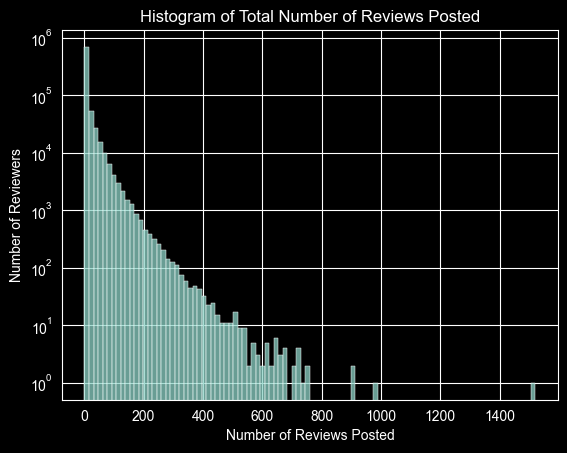

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'total_reviews':np.uint16})
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['total_reviews'], bins=100)
    plt.xlabel("Number of Reviews Posted")
    plt.ylabel("Number of Reviewers")
    plt.title("Histogram of Total Number of Reviews Posted")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")

As we can see, User_ID 108416619844777498346 (the one who posted 1,520 reviews) is a complete anomaly within this list, posing 50% more reviews than the next highest reviewer. None of his reviews within this dataset have any pictures. This will be useful for me because this is a clear example of an anomaly.

Now to try to finish up this project. I need to create one JSON file with these attributes:
* the user id (primary key)
* standard deviation of inter_review times
* average number of pictures posted in reviews
* maximum number of pictures posted in reviews
* average word count in reviews
* standard deviation of ratings (for the rating patterns part)

In addition, I wish to create a second JSON file with these attributes:
* Google Maps ID
* Review count
* Number of reviews with pictures
* standard deviation of inter_review times
* Average pictures posted in reviews
* Standard deviation in ratings

Since I want word count, I will be starting from the original review file. I will remove the line that drops the label for the review.

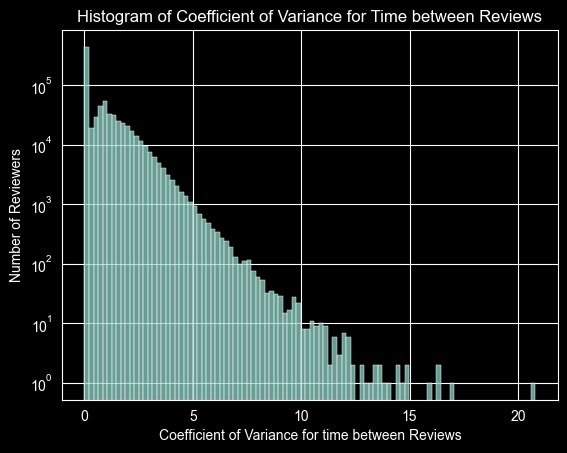

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_json('data/rgur_data.json', lines=True,)
    # we use bins = 51 since we now that we have 0-50 pictures in the reviews.
    plot = sns.histplot(df['cov_time'], bins=100)
    plt.xlabel("Coefficient of Variance for time between Reviews")
    plt.ylabel("Number of Reviewers")
    plt.title("Histogram of Coefficient of Variance for Time between Reviews")
    #using logarithmic scale because we would not be able to see anything.
    plot.set_yscale('log')
    plt.show()
except FileNotFoundError:
    print("File not found")

In order to run the DBSCAN algorithm, I must run another algorithm in order to find my epsilon.

Reading File...
Doing log transformations...
Scaling features...


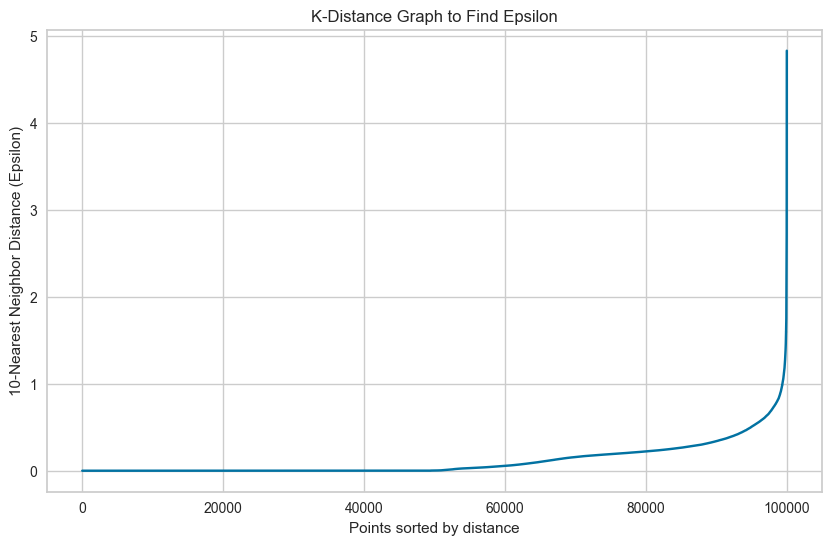

In [12]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
try:
    print("Reading File...")
    # this data is only 200 MB, so I can just read the whole thing. Using np.float16 to reduce memory usage.
    # Note, if your total word count is greater than 65536, change 'total_words':np.uint16 to 'total_words':np.uint32
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16}, nrows=100000)
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['total_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['total_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    # 1. Choose your k (min_samples)
    # Rule of thumb: min_samples = 2 * number of features
    k = 10
    # 2. Fit NearestNeighbors
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)

    # 3. Sort the distances to the kth neighbor (the last column)
    distances = np.sort(distances[:, k-1], axis=0)

    # 4. Plot the distances
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title('K-Distance Graph to Find Epsilon')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{k}-Nearest Neighbor Distance (Epsilon)')
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("File not found")



This gets me an epsilon of... 0.8

Reading File...
Doing log transformations...
Scaling features...
Running DBSCAN...
Creating Scatter plot...
     log_reviews  log_pics  log_words  cov_time  cov_rating
PC1     0.565595  0.318389   0.417656  0.524937    0.358796
PC2     0.078754  0.712879  -0.206624  0.097169   -0.658382
cluster
 0    92874
 1     3864
 2     2620
-1      626
 3       16
Name: count, dtype: int64


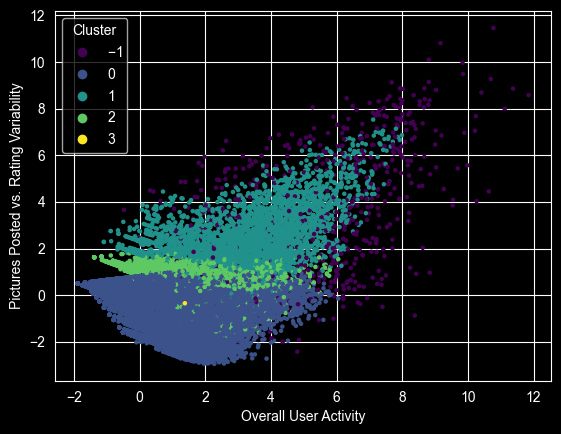

In [8]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
try:
    print("Reading File...")
    # this data is only 200 MB, so I can just read the whole thing. Using np.float16 to reduce memory usage.
    # Note, if your total word count is greater than 65536, change 'total_words':np.uint16 to 'total_words':np.uint32
    df = pd.read_json('data/rgur_data.json', lines=True, dtype={'cov_time':np.float32, 'cov_rating':np.float32, 'total_reviews':np.uint16, 'total_pictures':np.uint16, 'total_words':np.uint16}, nrows=100000)
    # keep user_id, total_pictures, total_reviews, total_words, cov_time, cov_rating
    print("Doing log transformations...")
    #doing log transformations to reduce the scale of the tail.
    df['log_reviews'] = np.log1p(df['total_reviews'], dtype=np.float32)
    df['log_pics'] = np.log1p(df['total_pictures'], dtype=np.float32)
    df['log_words'] = np.log1p(df['total_words'], dtype=np.float32)
    df.drop(columns=['max_pics', 'rev_with_pics', 'max_words', 'rev_with_words', 'avg_pictures', 'pics_percent','total_pictures', 'total_reviews', 'total_pictures'], inplace=True)
    features = df[['log_reviews', 'log_pics', 'log_words', 'cov_time', 'cov_rating']]
    # scale features
    print("Scaling features...")
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    # run DBSCAN on features, add cluster to df afterwards
    print("Running DBSCAN...")
    model = DBSCAN(eps=0.8, min_samples=10)
    labels = model.fit_predict(X)
    df['cluster'] = labels
    # create scatter plot
    print("Creating Scatter plot...")
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(X)
    pc_df = pd.DataFrame(
        pca.components_,
        columns=features.columns,
        index=['PC1', 'PC2']
    )
    print(pc_df)
    print(df['cluster'].value_counts())
    scatter = plt.scatter(X2[:,0], X2[:,1], c=df['cluster'], s=5, cmap='viridis')
    legend = plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.xlabel("Overall User Activity")
    plt.ylabel("Pictures Posted vs. Rating Variability")
    plt.show()
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print("Some other error occurred:\n"+str(e))
